This step evaluates the temporal availability of the historical and recent detector datasets for the selected intersections. Since the older JSON files and the newer JSON files have slightly different internal structures, a unified parser is used to extract the common traffic count information. The goal is to identify full, partial, and empty days and to determine which periods are suitable for subsequent approach-based aggregation and LSTM modeling.
****

***
**LSA1-specific output folder + usable-day extraction**
***

In [1]:
from pathlib import Path
import pandas as pd

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
DAY_SUMMARY_CSV = BASE_DIR / "historical_availability_analysis" / "historical_recent_day_summary.csv"

LSA_NAME = "LD-LSA1"
OUT_DIR = BASE_DIR / "LSA1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_USABLE_DAYS_CSV = OUT_DIR / "LSA1_usable_days.csv"
OUT_DAY_STATUS_CSV = OUT_DIR / "LSA1_day_status_summary.csv"

# ============================================================
# LOAD
# ============================================================

day_summary = pd.read_csv(DAY_SUMMARY_CSV)

# ============================================================
# FILTER FOR LSA16
# ============================================================

lsa_day_summary = day_summary[day_summary["lsa"] == LSA_NAME].copy()

usable_days = lsa_day_summary[
    lsa_day_summary["model_usability"].isin(["usable", "usable_partial"])
].copy()

usable_days = usable_days.sort_values(["date_str", "source_period"]).reset_index(drop=True)

# save
lsa_day_summary.to_csv(OUT_DAY_STATUS_CSV, index=False, encoding="utf-8-sig")
usable_days.to_csv(OUT_USABLE_DAYS_CSV, index=False, encoding="utf-8-sig")

print("Saved:")
print(OUT_DAY_STATUS_CSV)
print(OUT_USABLE_DAYS_CSV)

print("\nUsable day counts:")
print(usable_days.groupby(["source_period", "model_usability"]).size())

print("\nFirst usable days:")
print(usable_days[["date_str", "source_period", "day_status", "model_usability"]].head(20))

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_day_status_summary.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_usable_days.csv

Usable day counts:
source_period  model_usability
historical     usable             28
               usable_partial      2
recent         usable             13
               usable_partial     27
dtype: int64

First usable days:
      date_str source_period   day_status model_usability
0   2025-05-26    historical  partial_day  usable_partial
1   2025-05-27    historical     full_day          usable
2   2025-05-28    historical     full_day          usable
3   2025-05-29    historical     full_day          usable
4   2025-05-30    historical     full_day          usable
5   2025-05-31    historical     full_day          usable
6   2025-06-01    historical     full_day          usable
7   2025-06-02    historical     full_day          usable
8   2025-06-03    historical     full_day          usable
9   2025-06-04    

**Approach-based count aggregation for LSA1**

This step combines the historical and recent detector JSON files for LSA16 and aggregates the selected detector counts to the approach level. The result is a continuous 15-minute approach-based traffic count dataset for the west, south, east, and north inflow directions of LSA1, which forms the basis for intersection-specific forecasting.

In [2]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")

HIST_DIR = BASE_DIR / "Six_Months_Data" / "LD-LSA1"
RECENT_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\LD-LSA1")

OUT_DIR = BASE_DIR / "LSA1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_RAW_CSV = OUT_DIR / "LSA1_raw_long.csv"
OUT_APPROACH_CSV = OUT_DIR / "LSA1_approach_counts_15min.csv"
OUT_MAPPING_CSV = OUT_DIR / "LSA1_mapping_summary.csv"

TIMEZONE_LOCAL = "Europe/Berlin"

# ============================================================
# LSA1 MAPPING
# ============================================================

LSA1_MAPPING = {
    "street_names": {
        "west": "Rheinstraße",
        "south": "Paul-von-Denis-Straße",
        "east": "Rheinstraße",
        "north": "Maximilianstraße",
    },
    "inflow": {
        "west": [7, 9],
        "east": [14, 24, 26],
        "north": [40, 28, 30],
    },
    "outflow": {},
    "excluded_faulty_detectors": {
        "south": [11]
    }
}

# ============================================================
# HELPERS
# ============================================================

def parse_json_file(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_date_from_filename(path: Path):
    return path.stem[:10]

def safe_get(dct, keys, default=np.nan):
    cur = dct
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

# ============================================================
# READ FILES
# ============================================================

all_files = []
if HIST_DIR.exists():
    all_files += [(p, "historical") for p in sorted(HIST_DIR.glob("*.json"))]
if RECENT_DIR.exists():
    all_files += [(p, "recent") for p in sorted(RECENT_DIR.glob("*.json"))]

rows = []

for path, source_period in all_files:
    try:
        data = parse_json_file(path)
    except Exception as e:
        print(f"Could not read {path.name}: {e}")
        continue

    timeframes = data.get("timeFrames", [])

    for tf in timeframes:
        ts_utc = tf.get("timestamp")
        detectors = tf.get("detectors", [])

        if len(detectors) == 0:
            continue

        for det in detectors:
            rows.append({
                "source_period": source_period,
                "source_file": path.name,
                "date_from_name": extract_date_from_filename(path),
                "timestamp_utc": ts_utc,
                "detector_id": safe_get(det, ["id"]),
                "count": safe_get(det, ["reading", "count", "value"]),
            })

raw_df = pd.DataFrame(rows)

# ============================================================
# CLEAN / TIMESTAMPS
# ============================================================

raw_df["timestamp_utc"] = pd.to_datetime(raw_df["timestamp_utc"], utc=True, errors="coerce")
raw_df["timestamp_berlin"] = raw_df["timestamp_utc"].dt.tz_convert(TIMEZONE_LOCAL)
raw_df["detector_id"] = pd.to_numeric(raw_df["detector_id"], errors="coerce")
raw_df["count"] = pd.to_numeric(raw_df["count"], errors="coerce")

raw_df = raw_df.dropna(subset=["timestamp_berlin", "detector_id", "count"]).copy()
raw_df = raw_df.sort_values("timestamp_berlin").reset_index(drop=True)

raw_df.to_csv(OUT_RAW_CSV, index=False, encoding="utf-8-sig")

print("Saved raw long table:")
print(OUT_RAW_CSV)
print("Raw shape:", raw_df.shape)

# ============================================================
# SAVE MAPPING SUMMARY
# ============================================================

mapping_rows = []
for approach, dets in LSA1_MAPPING["inflow"].items():
    mapping_rows.append({
        "lsa": "LD-LSA1",
        "approach": approach,
        "street_name": LSA1_MAPPING["street_names"].get(approach, ""),
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "inflow"
    })

for approach, dets in LSA1_MAPPING["outflow"].items():
    mapping_rows.append({
        "lsa": "LD-LSA1",
        "approach": approach,
        "street_name": "",
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "outflow"
    })

# add note about excluded faulty detector
for approach, dets in LSA1_MAPPING["excluded_faulty_detectors"].items():
    mapping_rows.append({
        "lsa": "LD-LSA1",
        "approach": approach,
        "street_name": LSA1_MAPPING["street_names"].get(approach, ""),
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "excluded_faulty"
    })

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.to_csv(OUT_MAPPING_CSV, index=False, encoding="utf-8-sig")

print("\nSaved mapping summary:")
print(OUT_MAPPING_CSV)

# ============================================================
# AGGREGATE INFLOW COUNTS
# ============================================================

approach_tables = []

for approach, dets in LSA1_MAPPING["inflow"].items():
    temp = raw_df[raw_df["detector_id"].isin(dets)].copy()

    agg = (
        temp.groupby("timestamp_berlin", as_index=False)
        .agg(count=("count", "sum"))
    )

    agg = agg.rename(columns={"count": f"LSA1_{approach}_count"})
    approach_tables.append(agg)

# merge all approaches
approach_df = None
for tbl in approach_tables:
    if approach_df is None:
        approach_df = tbl.copy()
    else:
        approach_df = approach_df.merge(tbl, on="timestamp_berlin", how="outer")

approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], utc=True, errors="coerce")
approach_df = approach_df.sort_values("timestamp_berlin").reset_index(drop=True)

# helper columns
approach_df["date"] = approach_df["timestamp_berlin"].dt.strftime("%Y-%m-%d")
approach_df["time"] = approach_df["timestamp_berlin"].dt.strftime("%H:%M")
approach_df["hour"] = approach_df["timestamp_berlin"].dt.hour
approach_df["weekday"] = approach_df["timestamp_berlin"].dt.day_name()

approach_df.to_csv(OUT_APPROACH_CSV, index=False, encoding="utf-8-sig")

print("\nSaved LSA1 approach dataset:")
print(OUT_APPROACH_CSV)
print("Approach shape:", approach_df.shape)
print("\nPreview:")
print(approach_df.head())

Saved raw long table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_raw_long.csv
Raw shape: (269346, 7)

Saved mapping summary:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_mapping_summary.csv

Saved LSA1 approach dataset:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_approach_counts_15min.csv
Approach shape: (6413, 8)

Preview:
           timestamp_berlin  LSA1_west_count  LSA1_east_count  \
0 2025-05-26 09:30:00+00:00              450             1800   
1 2025-05-26 09:45:00+00:00              200              329   
2 2025-05-26 10:00:00+00:00              205              308   
3 2025-05-26 10:15:00+00:00              187              336   
4 2025-05-26 10:30:00+00:00              186              320   

   LSA1_north_count        date   time  hour weekday  
0                 0  2025-05-26  09:30     9  Monday  
1               156  2025-05-26  09:45     9  Monday  
2               122  2025-05-26  10:00    10  Monday  
3        

 *** 
### **Exploratory analysis of the LSA1 approach-based dataset**

This step checks the completeness and temporal structure of the LSA10 approach-level count dataset and visualizes the main traffic patterns before forecasting.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1")
APPROACH_CSV = BASE_DIR / "LSA1_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

# safer parsing for mixed +01:00 / +02:00 timestamps
df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")

# convert to Europe/Berlin local time and remove timezone for easier plotting/grouping
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [
    "LSA1_west_count",
    "LSA1_east_count",
    "LSA1_north_count",
]

print("Shape:", df.shape)

print("\nMissing values per count column:")
print(df[count_cols].isna().sum())

print("\nTime range:")
print(df["timestamp_berlin"].min(), "to", df["timestamp_berlin"].max())

# time gap check
time_diff = df["timestamp_berlin"].diff().value_counts().sort_index()
print("\nMost common time differences:")
print(time_diff.head(10))

print("\nBasic statistics:")
print(df[count_cols].describe())

Shape: (6413, 8)

Missing values per count column:
LSA1_west_count     0
LSA1_east_count     0
LSA1_north_count    0
dtype: int64

Time range:
2025-05-26 11:30:00 to 2026-04-16 08:45:00

Most common time differences:
timestamp_berlin
0 days 00:15:00    6379
0 days 00:30:00      21
0 days 01:00:00       1
0 days 01:15:00       1
0 days 01:45:00       2
0 days 07:15:00       1
0 days 08:15:00       1
0 days 19:45:00       1
1 days 00:15:00       1
1 days 00:30:00       1
Name: count, dtype: int64

Basic statistics:
       LSA1_west_count  LSA1_east_count  LSA1_north_count
count      6413.000000      6413.000000       6413.000000
mean        109.187588       165.589428         69.990176
std          80.285873       123.374538         53.314517
min           0.000000         0.000000          0.000000
25%          27.000000        41.000000         16.000000
50%         104.000000       156.000000         63.000000
75%         190.000000       284.000000        122.000000
max         481.0

**1)Blockwise split for LSA1 forecasting**
Since the LSA1 dataset contains a historical block and a separate recent block, the modeling workflow is defined blockwise. The historical data are used for training, while the recent data are divided into validation and test subsets. This avoids constructing sequences across the long temporal gap between the two periods.

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1")
APPROACH_CSV = BASE_DIR / "LSA1_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

# Safe timestamp parsing
df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [
    "LSA1_west_count",
    "LSA1_east_count",
    "LSA1_north_count",
]

data = df[["timestamp_berlin"] + count_cols].copy()
data[count_cols] = data[count_cols].ffill().bfill()

# ============================================================
# BLOCKWISE SPLIT
# ============================================================

historical_df = data[data["timestamp_berlin"] < "2026-01-01"].copy()
recent_df = data[data["timestamp_berlin"] >= "2026-01-01"].copy()

print("Historical shape:", historical_df.shape)
print("Recent shape:", recent_df.shape)

print("\nHistorical range:")
print(historical_df["timestamp_berlin"].min(), "to", historical_df["timestamp_berlin"].max())

print("\nRecent range:")
print(recent_df["timestamp_berlin"].min(), "to", recent_df["timestamp_berlin"].max())

Historical shape: (2787, 4)
Recent shape: (3626, 4)

Historical range:
2025-05-26 11:30:00 to 2025-06-24 12:00:00

Recent range:
2026-03-01 01:15:00 to 2026-04-16 08:45:00


**2) Validation-test split within the recent period**
The recent data are split chronologically into validation and test subsets in order to preserve the temporal order of observations.

In [4]:
# ============================================================
# SPLIT RECENT INTO VALIDATION / TEST
# ============================================================

n_recent = len(recent_df)
val_end = int(n_recent * 0.50)

val_df = recent_df.iloc[:val_end].copy()
test_df = recent_df.iloc[val_end:].copy()
train_df = historical_df.copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain range:")
print(train_df["timestamp_berlin"].min(), "to", train_df["timestamp_berlin"].max())

print("\nValidation range:")
print(val_df["timestamp_berlin"].min(), "to", val_df["timestamp_berlin"].max())

print("\nTest range:")
print(test_df["timestamp_berlin"].min(), "to", test_df["timestamp_berlin"].max())

Train: (2787, 4)
Validation: (1813, 4)
Test: (1813, 4)

Train range:
2025-05-26 11:30:00 to 2025-06-24 12:00:00

Validation range:
2026-03-01 01:15:00 to 2026-03-23 08:45:00

Test range:
2026-03-23 09:00:00 to 2026-04-16 08:45:00


****
**Creation of clipped copies**
it cuts extremely large values above the 99th percentile of the training data

In [5]:
import pandas as pd

train_clip = train_df.copy()
val_clip = val_df.copy()
test_clip = test_df.copy()

clip_info = []

for col in count_cols:
    upper_cap = train_df[col].quantile(0.99)

    train_clip[col] = train_clip[col].clip(upper=upper_cap)
    val_clip[col] = val_clip[col].clip(upper=upper_cap)
    test_clip[col] = test_clip[col].clip(upper=upper_cap)

    clip_info.append({
        "feature": col,
        "upper_cap_99pct_train": upper_cap,
        "train_max_before": train_df[col].max(),
        "val_max_before": val_df[col].max(),
        "test_max_before": test_df[col].max(),
        "train_max_after": train_clip[col].max(),
        "val_max_after": val_clip[col].max(),
        "test_max_after": test_clip[col].max(),
    })
    LOOKBACK = 12      # or 12 if you want
HORIZON = 1       # 1=15min, 2=30min, 4=60min

clip_info_df = pd.DataFrame(clip_info)
print(clip_info_df)

            feature  upper_cap_99pct_train  train_max_before  val_max_before  \
0   LSA1_west_count                 256.14               481             359   
1   LSA1_east_count                 398.00              1800             416   
2  LSA1_north_count                 163.00               206             306   

   test_max_before  train_max_after  val_max_after  test_max_after  
0              310           256.14         256.14          256.14  
1              439           398.00         398.00          398.00  
2              365           163.00         163.00          163.00  


**Scale the clipped data and make sequences**

In [6]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler_clip = MinMaxScaler()
scaler_clip.fit(train_clip[count_cols])

train_scaled_clip = scaler_clip.transform(train_clip[count_cols])
val_scaled_clip = scaler_clip.transform(val_clip[count_cols])
test_scaled_clip = scaler_clip.transform(test_clip[count_cols])

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

X_train_clip, y_train_clip = create_sequences(train_scaled_clip, LOOKBACK, HORIZON)
X_val_clip, y_val_clip = create_sequences(val_scaled_clip, LOOKBACK, HORIZON)
X_test_clip, y_test_clip = create_sequences(test_scaled_clip, LOOKBACK, HORIZON)

print("X_train_clip:", X_train_clip.shape, "y_train_clip:", y_train_clip.shape)
print("X_val_clip:  ", X_val_clip.shape, "y_val_clip:", y_val_clip.shape)
print("X_test_clip: ", X_test_clip.shape, "y_test_clip:", y_test_clip.shape)

X_train_clip: (2775, 12, 3) y_train_clip: (2775, 3)
X_val_clip:   (1801, 12, 3) y_val_clip: (1801, 3)
X_test_clip:  (1801, 12, 3) y_test_clip: (1801, 3)


**Clipped naive baseline**

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# naive prediction = last observed step in each input sequence
y_pred_naive_scaled_clip = X_test_clip[:, -1, :]

# back to original scale
y_test_actual_clip = scaler_clip.inverse_transform(y_test_clip)
y_pred_naive_actual_clip = scaler_clip.inverse_transform(y_pred_naive_scaled_clip)

overall_mae_naive_clip = mean_absolute_error(y_test_actual_clip, y_pred_naive_actual_clip)
overall_rmse_naive_clip = rmse(y_test_actual_clip, y_pred_naive_actual_clip)
overall_mse_naive_clip = mean_squared_error(y_test_actual_clip, y_pred_naive_actual_clip)

print("LSA1 Naive baseline (clipped):")
print("MAE :", round(overall_mae_naive_clip, 3))
print("RMSE:", round(overall_rmse_naive_clip, 3))
print("MSE :", round(overall_mse_naive_clip, 3))

LSA1 Naive baseline (clipped):
MAE : 13.755
RMSE: 21.321
MSE : 454.577


**Clipped LSTM Model**

**Lookback window**

The lookback window defines how many previous time steps are used as input for forecasting. In this study, one-hour and three-hour history windows were tested depending on the complexity of the intersection-specific traffic patterns.

**Patience**

Patience defines how many consecutive epochs without validation improvement are tolerated before training is stopped early.

**LSTM**

The LSTM model is a recurrent neural network architecture that is designed to learn temporal dependencies in sequential data. It uses past traffic observations to predict future traffic conditions and is particularly suitable for time series with short-term and medium-term dynamics.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train_clip.shape[2]

model_clip = Sequential([
    Input(shape=(LOOKBACK, n_features)),
    LSTM(64),
    Dropout(0.2),
    Dense(n_features)
])

model_clip.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_clip = model_clip.fit(
    X_train_clip, y_train_clip,
    validation_data=(X_val_clip, y_val_clip),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0792 - val_loss: 0.0158
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0135 - val_loss: 0.0089
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0099 - val_loss: 0.0076
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0086 - val_loss: 0.0070
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0078 - val_loss: 0.0065
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0072 - val_loss: 0.0064
Epoch 7/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0070 - val_loss: 0.0060
Epoch 8/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0068 - val_loss: 0.0060
Epoch 9/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0063 - val_loss: 0.0058
Epoch 10/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0060 - val_loss: 0.0056
Epoch 11/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0063 - val_loss: 0.0056
Epoch 12/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0057 - val

**Evaluation of Clipped LSTM**

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred_lstm_scaled_clip = model_clip.predict(X_test_clip)
y_pred_lstm_actual_clip = scaler_clip.inverse_transform(y_pred_lstm_scaled_clip)

overall_mae_lstm_clip = mean_absolute_error(y_test_actual_clip, y_pred_lstm_actual_clip)
overall_mse_lstm_clip = mean_squared_error(y_test_actual_clip, y_pred_lstm_actual_clip)
overall_rmse_lstm_clip = np.sqrt(overall_mse_lstm_clip)

print("LSA1 Naive baseline (clipped):")
print("MAE :", round(overall_mae_naive_clip, 3))
print("MSE :", round(overall_mse_naive_clip, 3))
print("RMSE:", round(overall_rmse_naive_clip, 3))

print("\nLSA1 LSTM (clipped):")
print("MAE :", round(overall_mae_lstm_clip, 3))
print("MSE :", round(overall_mse_lstm_clip, 3))
print("RMSE:", round(overall_rmse_lstm_clip, 3))

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
LSA1 Naive baseline (clipped):
MAE : 13.755
MSE : 454.577
RMSE: 21.321

LSA1 LSTM (clipped):
MAE : 12.359
MSE : 377.599
RMSE: 19.432


**Approach-based comparison of naive baseline and LSTM**
This step compares the naive baseline and the LSTM model for each LSA1 approach separately using MAE and RMSE.

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rows = []

for i, feature in enumerate(count_cols):
    approach_name = feature.replace("LSA1_", "").replace("_count", "")

    naive_mae = mean_absolute_error(y_test_actual_clip[:, i], y_pred_naive_actual_clip[:, i])
    lstm_mae = mean_absolute_error(y_test_actual_clip[:, i], y_pred_lstm_actual_clip[:, i])

    naive_mse = mean_squared_error(y_test_actual_clip[:, i], y_pred_naive_actual_clip[:, i])
    lstm_mse = mean_squared_error(y_test_actual_clip[:, i], y_pred_lstm_actual_clip[:, i])

    naive_rmse = np.sqrt(naive_mse)
    lstm_rmse = np.sqrt(lstm_mse)

    rows.append({
        "approach": approach_name,

        "naive_MAE": naive_mae,
        "lstm_MAE": lstm_mae,

        "naive_MSE": naive_mse,
        "lstm_MSE": lstm_mse,

        "naive_RMSE": naive_rmse,
        "lstm_RMSE": lstm_rmse,

        "mae_improvement_percent": (naive_mae - lstm_mae) / naive_mae * 100,
        "mse_improvement_percent": (naive_mse - lstm_mse) / naive_mse * 100,
        "rmse_improvement_percent": (naive_rmse - lstm_rmse) / naive_rmse * 100,
    })

approach_comparison_df = pd.DataFrame(rows)
print(approach_comparison_df)

# optional save
from pathlib import Path
OUT_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1")
approach_comparison_df.to_csv(OUT_DIR / "LSA1_clipped_per_approach_comparison.csv", index=False, encoding="utf-8-sig")
print("Saved:", OUT_DIR / "LSA1_clipped_per_approach_comparison.csv")

  approach  naive_MAE   lstm_MAE   naive_MSE    lstm_MSE  naive_RMSE  \
0     west  13.633359  12.771005  442.530725  361.478086   21.036414   
1     east  17.513604  15.662236  680.949473  590.798339   26.095009   
2    north  10.117157   8.644830  240.251527  180.521650   15.500049   

   lstm_RMSE  mae_improvement_percent  mse_improvement_percent  \
0  19.012577                 6.325325                18.315709   
1  24.306344                10.571028                13.239034   
2  13.435835                14.552778                24.861393   

   rmse_improvement_percent  
0                  9.620638  
1                  6.854433  
2                 13.317472  
Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_clipped_per_approach_comparison.csv


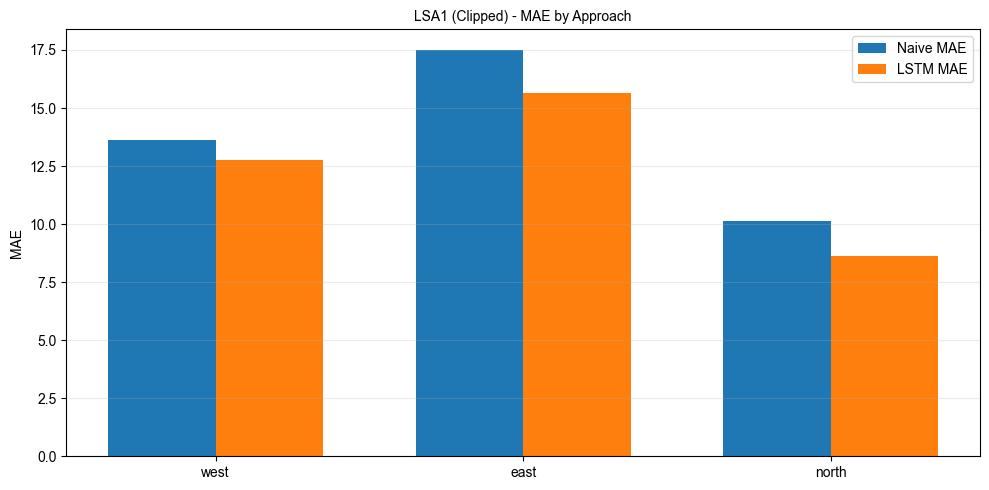

In [14]:
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

import numpy as np

x = np.arange(len(approach_comparison_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, approach_comparison_df["naive_MAE"], width, label="Naive MAE")
plt.bar(x + width/2, approach_comparison_df["lstm_MAE"], width, label="LSTM MAE")

plt.xticks(x, approach_comparison_df["approach"])
plt.ylabel("MAE")
plt.title("LSA1 (Clipped) - MAE by Approach")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

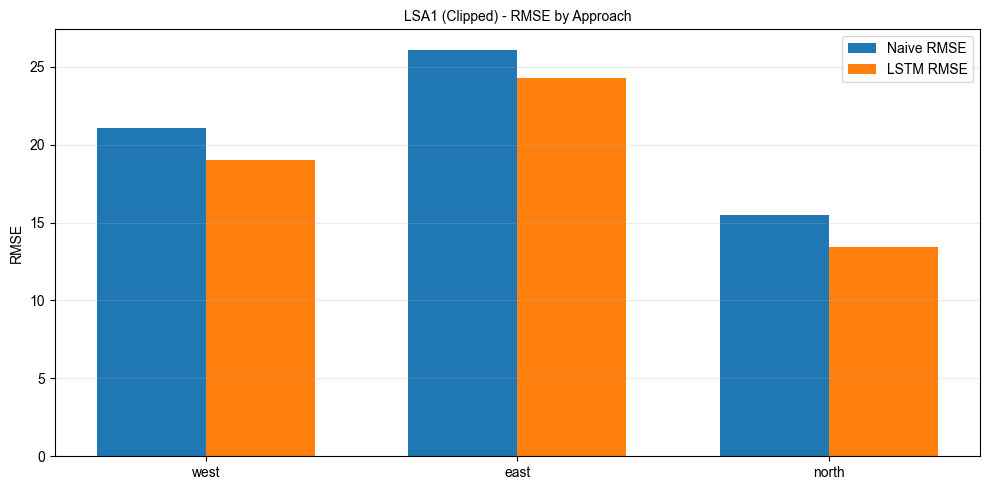

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, approach_comparison_df["naive_RMSE"], width, label="Naive RMSE")
plt.bar(x + width/2, approach_comparison_df["lstm_RMSE"], width, label="LSTM RMSE")

plt.xticks(x, approach_comparison_df["approach"])
plt.ylabel("RMSE")
plt.title("LSA1 (Clipped) - RMSE by Approach")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

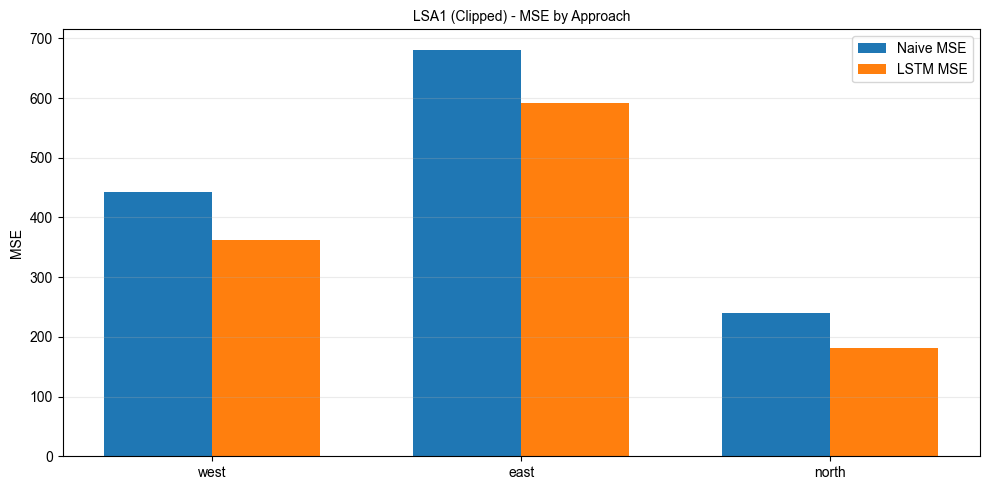

In [16]:
plt.figure(figsize=(10, 5))

plt.bar(x - width/2, approach_comparison_df["naive_MSE"], width, label="Naive MSE")
plt.bar(x + width/2, approach_comparison_df["lstm_MSE"], width, label="LSTM MSE")

plt.xticks(x, approach_comparison_df["approach"])
plt.ylabel("MSE")
plt.title("LSA1 (Clipped) - MSE by Approach")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

MAE, MSE and RMSE were used to evaluate the prediction performance of the LSTM model and the naive baseline. These metrics were included because they describe prediction errors from slightly different perspectives.

MAE measures the average absolute difference between the observed and predicted traffic counts. It is easy to interpret because it is expressed in the same unit as the target variable, in this case vehicles. Therefore, MAE gives a direct indication of the average prediction error.

MSE measures the average squared difference between observed and predicted values. Since the errors are squared, larger prediction errors receive a stronger penalty. For this reason, MSE is useful for identifying whether a model produces large individual deviations.

RMSE is the square root of MSE. Like MAE, it is expressed in the original unit of the target variable, but it remains more sensitive to larger errors than MAE. Therefore, RMSE provides an interpretable measure of the typical error magnitude while still reflecting the influence of larger deviations.

In this thesis, MAE is used to assess the average prediction error, while MSE and RMSE are used to evaluate the model’s sensitivity to larger prediction errors. If the LSTM model achieves lower values than the naive baseline across these metrics, this indicates an improvement in short-term traffic count prediction.

   model        MAE         MSE       RMSE
0  Naive  13.754707  454.577241  21.320817
1   LSTM  12.359357  377.599358  19.431916


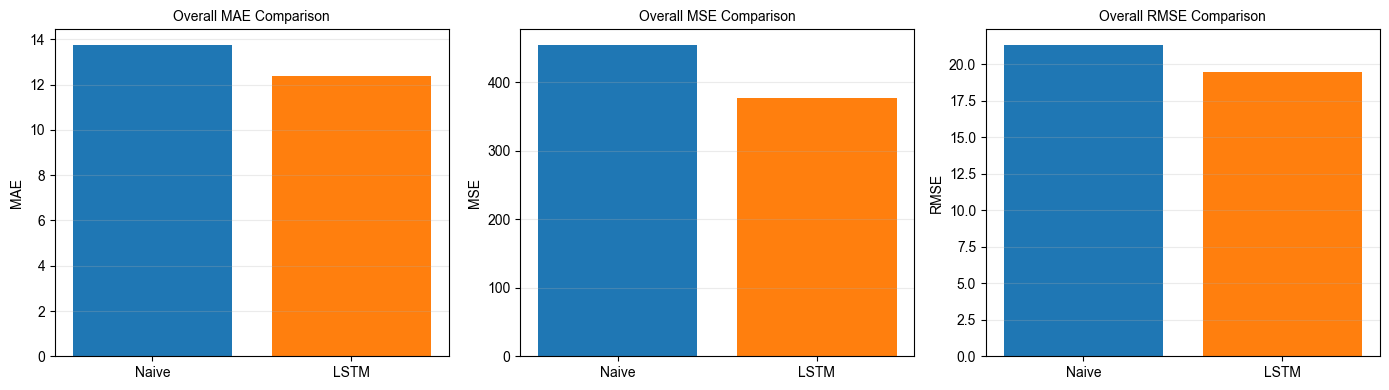

In [17]:
overall_df = pd.DataFrame({
    "model": ["Naive", "LSTM"],
    "MAE": [overall_mae_naive_clip, overall_mae_lstm_clip],
    "MSE": [overall_mse_naive_clip, overall_mse_lstm_clip],
    "RMSE": [overall_rmse_naive_clip, overall_rmse_lstm_clip]
})

print(overall_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(overall_df["model"], overall_df["MAE"], color=["tab:blue", "tab:orange"])
axes[0].set_title("Overall MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(overall_df["model"], overall_df["MSE"], color=["tab:blue", "tab:orange"])
axes[1].set_title("Overall MSE Comparison")
axes[1].set_ylabel("MSE")
axes[1].grid(axis="y", alpha=0.25)

axes[2].bar(overall_df["model"], overall_df["RMSE"], color=["tab:blue", "tab:orange"])
axes[2].set_title("Overall RMSE Comparison")
axes[2].set_ylabel("RMSE")
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

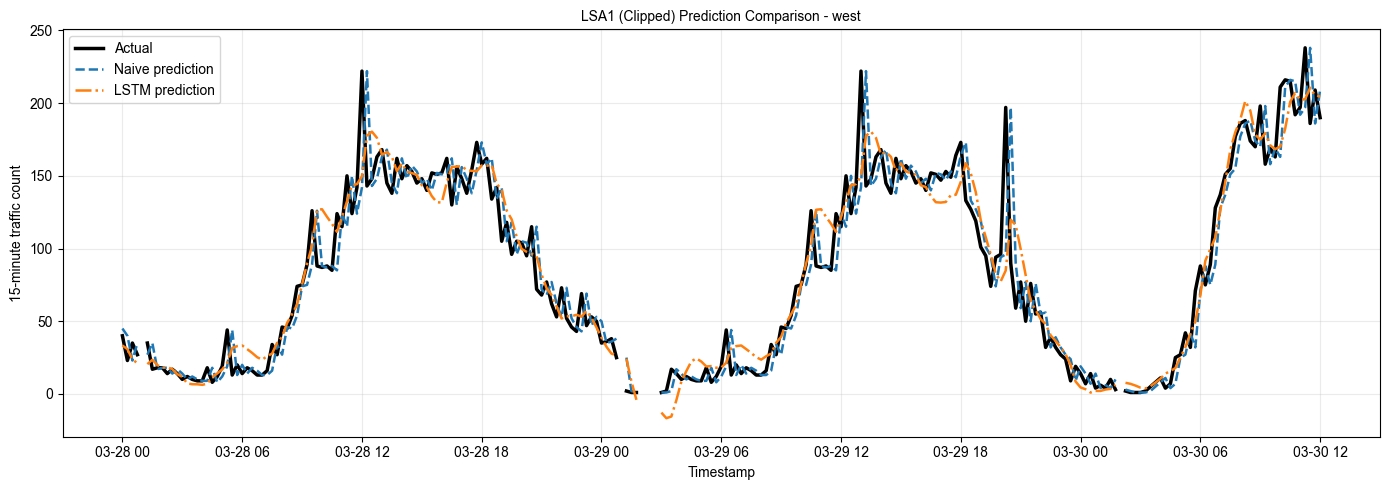

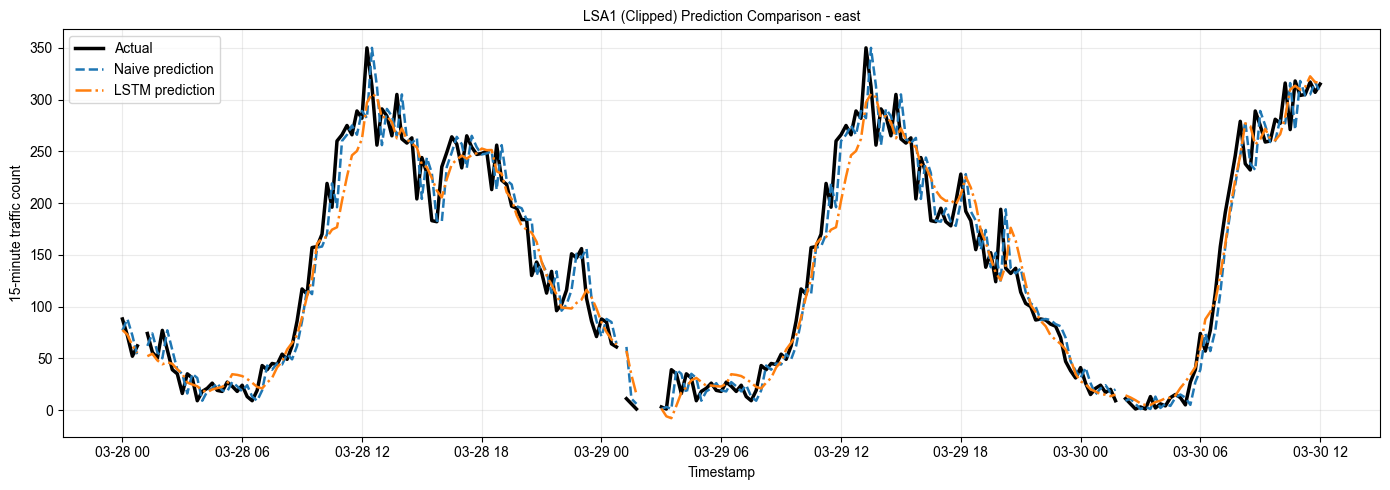

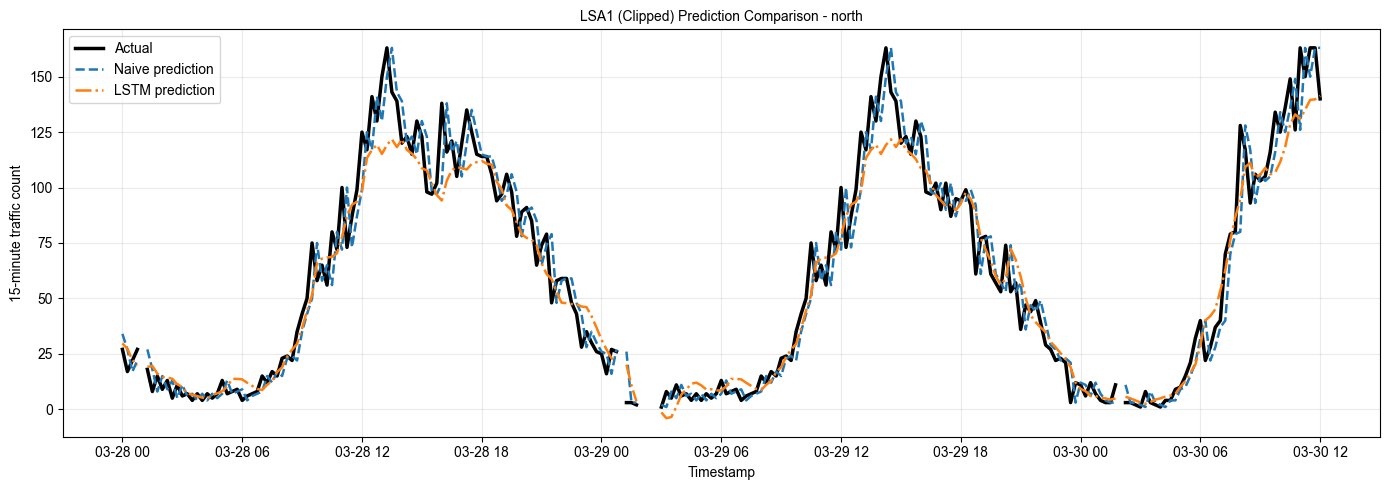

In [13]:
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

import pandas as pd

plot_features = count_cols.copy()

full_test_timestamps = test_df["timestamp_berlin"].reset_index(drop=True)
aligned_test_timestamps = full_test_timestamps.iloc[
    LOOKBACK + HORIZON - 1 : LOOKBACK + HORIZON - 1 + len(y_test_actual_clip)
].reset_index(drop=True)

window_start = pd.Timestamp("2026-03-28")
window_end   = pd.Timestamp("2026-03-30 23:59:59")

window_mask = (aligned_test_timestamps >= window_start) & (aligned_test_timestamps <= window_end)
plot_timestamps = aligned_test_timestamps[window_mask].reset_index(drop=True)

for feature in plot_features:
    idx = count_cols.index(feature)

    plot_df = pd.DataFrame({
        "timestamp": plot_timestamps,
        "actual": y_test_actual_clip[window_mask, idx],
        "naive": y_pred_naive_actual_clip[window_mask, idx],
        "lstm": y_pred_lstm_actual_clip[window_mask, idx],
    })

    plot_df["gap"] = plot_df["timestamp"].diff() > pd.Timedelta(minutes=15)
    plot_df["segment"] = plot_df["gap"].cumsum()

    plt.figure(figsize=(14, 5))

    for seg_id, seg in plot_df.groupby("segment"):
        plt.plot(seg["timestamp"], seg["actual"],
                 color="black", linewidth=2.5,
                 label="Actual" if seg_id == 0 else "")
        plt.plot(seg["timestamp"], seg["naive"],
                 color="tab:blue", linestyle="--", linewidth=1.8,
                 label="Naive prediction" if seg_id == 0 else "")
        plt.plot(seg["timestamp"], seg["lstm"],
                 color="tab:orange", linestyle="-.", linewidth=1.8,
                 label="LSTM prediction" if seg_id == 0 else "")

    plt.title(f"LSA1 (Clipped) Prediction Comparison - {feature.replace('LSA1_', '').replace('_count', '')}")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

For LSA1, a sensitivity analysis with outlier clipping was performed because the east approach contained extremely large traffic counts relative to its normal range. After capping values above the 99th percentile of the training distribution, both the naive baseline and the LSTM model showed improved performance. The clipped LSTM achieved lower MAE and RMSE values than the clipped naive baseline, indicating that the sequence-based model remains beneficial even for this more difficult intersection. The results also suggest that extreme values had a measurable influence on model performance and that controlled clipping can improve the stability of the forecasting framework for noisy detector data.

The selection of the lookback window was adapted to the characteristics of each intersection. For LSA16 and LSA10, a lookback of four 15-minute intervals, corresponding to one hour of traffic history, was sufficient because these intersections provided relatively stable temporal patterns and strong historical training data. For LSA1, a longer lookback of twelve 15-minute intervals, corresponding to three hours, was tested because the intersection exhibited a more challenging forecasting structure with shorter historical coverage, greater irregularity, and higher short-term variability. Similarly, outlier clipping was not applied uniformly across all intersections. LSA16 and LSA10 were modeled using their original count series because their data already produced stable and strong forecasting performance. In contrast, LSA1 contained extremely large values, particularly on the east approach, which justified an additional sensitivity test using clipping at the 99th percentile of the training distribution. This was done to assess whether extreme values were disproportionately affecting the model behavior.

**Comparison LSA16 LSA10 LSA1**

   horizon_steps  horizon_minutes  naive_MAE  naive_RMSE   lstm_MAE  \
0              1               15   9.303580   14.665311   7.553996   
1              2               30   9.754036   15.357299   8.128274   
2              4               60  12.096086   17.956095   9.468053   
3              1               15   5.368455    8.677940   4.752985   
4              2               30   5.928695    9.597483   5.150604   
5              4               60   7.268002   11.799134   6.001282   
6              1               15  14.038327   22.297584  13.357653   
7              2               30  16.881453   26.919767  15.472847   
8              4               60  23.845700   37.532705  19.236276   

   lstm_RMSE  mae_improvement_percent  rmse_improvement_percent intersection  
0  11.770371                18.805498                 19.740053        LSA16  
1  12.515525                16.667589                 18.504386        LSA16  
2  13.874594                21.726311               

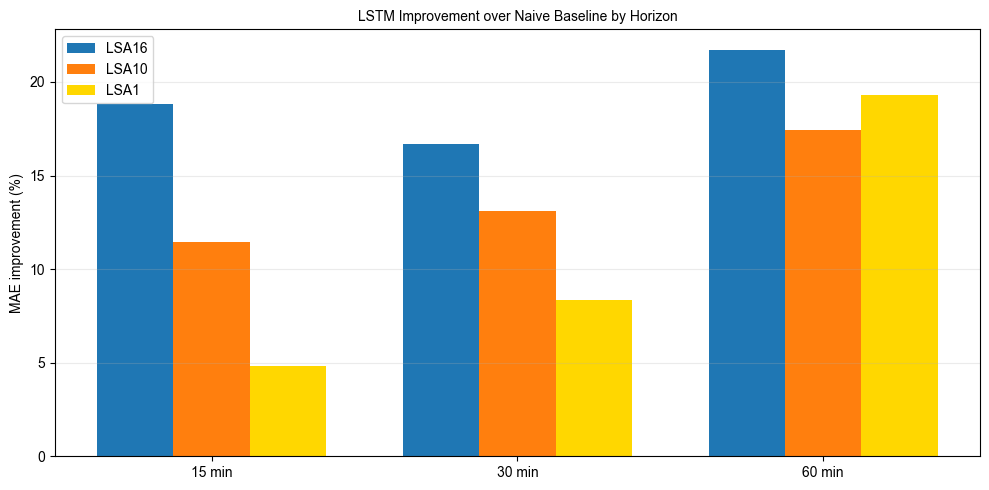

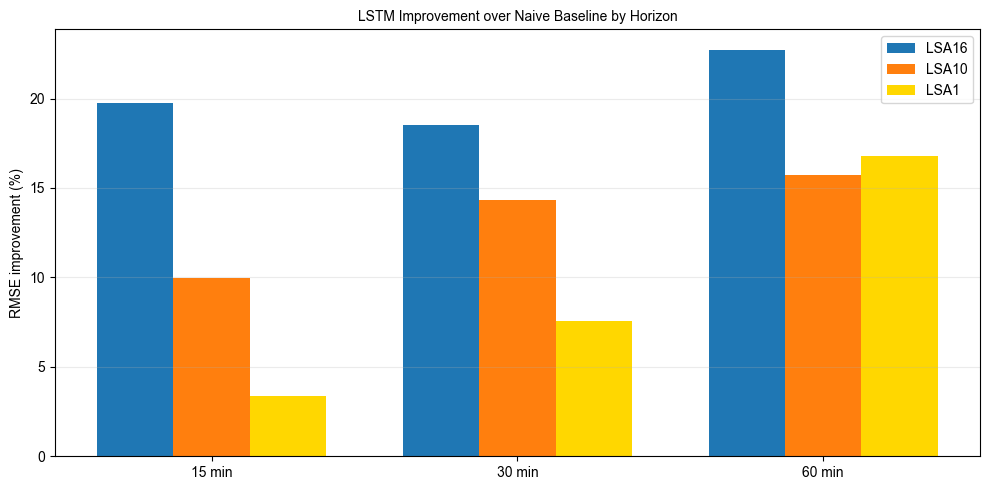

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

import numpy as np
from pathlib import Path

# ============================================================
# MANUAL RESULTS
# ============================================================

lsa16 = pd.DataFrame({
    "horizon_steps": [1, 2, 4],
    "horizon_minutes": [15, 30, 60],
    "naive_MAE": [9.303580, 9.754036, 12.096086],
    "naive_RMSE": [14.665311, 15.357299, 17.956095],
    "lstm_MAE": [7.553996, 8.128274, 9.468053],
    "lstm_RMSE": [11.770371, 12.515525, 13.874594],
    "mae_improvement_percent": [18.805498, 16.667589, 21.726311],
    "rmse_improvement_percent": [19.740053, 18.504386, 22.730446],
})
lsa16["intersection"] = "LSA16"

lsa10 = pd.DataFrame({
    "horizon_steps": [1, 2, 4],
    "horizon_minutes": [15, 30, 60],
    "naive_MAE": [5.368455, 5.928695, 7.268002],
    "naive_RMSE": [8.677940, 9.597483, 11.799134],
    "lstm_MAE": [4.752985, 5.150604, 6.001282],
    "lstm_RMSE": [7.814238, 8.220812, 9.941390],
    "mae_improvement_percent": [11.464562, 13.124149, 17.428720],
    "rmse_improvement_percent": [9.952843, 14.344092, 15.744750],
})
lsa10["intersection"] = "LSA10"

lsa1 = pd.DataFrame({
    "horizon_steps": [1, 2, 4],
    "horizon_minutes": [15, 30, 60],
    "naive_MAE": [14.038327, 16.881453, 23.845700],
    "naive_RMSE": [22.297584, 26.919767, 37.532705],
    "lstm_MAE": [13.357653, 15.472847, 19.236276],
    "lstm_RMSE": [21.547567, 24.881483, 31.223317],
    "mae_improvement_percent": [4.848680, 8.344104, 19.330210],
    "rmse_improvement_percent": [3.363670, 7.571699, 16.810374],
})
lsa1["intersection"] = "LSA1"

combined = pd.concat([lsa16, lsa10, lsa1], ignore_index=True)
print(combined)

# optional save
BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
OUT_CSV = BASE_DIR / "all_intersections_multi_horizon_comparison.csv"
combined.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_CSV)

# ============================================================
# PLOT MAE IMPROVEMENT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(lsa16["horizon_minutes"]))
width = 0.25

ax.bar(x - width, lsa16["mae_improvement_percent"], width,
       label="LSA16", color="tab:blue")

ax.bar(x, lsa10["mae_improvement_percent"], width,
       label="LSA10", color="tab:orange")

ax.bar(x + width, lsa1["mae_improvement_percent"], width,
       label="LSA1", color="gold")

ax.set_xticks(x)
ax.set_xticklabels([f"{m} min" for m in lsa16["horizon_minutes"]])
ax.set_ylabel("MAE improvement (%)")
ax.set_title("LSTM Improvement over Naive Baseline by Horizon")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT RMSE IMPROVEMENT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width, lsa16["rmse_improvement_percent"], width,
       label="LSA16", color="tab:blue")

ax.bar(x, lsa10["rmse_improvement_percent"], width,
       label="LSA10", color="tab:orange")

ax.bar(x + width, lsa1["rmse_improvement_percent"], width,
       label="LSA1", color="gold")

ax.set_xticks(x)
ax.set_xticklabels([f"{m} min" for m in lsa16["horizon_minutes"]])
ax.set_ylabel("RMSE improvement (%)")
ax.set_title("LSTM Improvement over Naive Baseline by Horizon")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

Across all three intersections, the LSTM model outperformed the naive persistence baseline at 15-minute, 30-minute, and 60-minute forecasting horizons. The magnitude of improvement varied by intersection, with LSA16 showing the strongest and most consistent gains, LSA10 also showing clear improvements, and LSA1 representing the most challenging case. For all intersections, the relative advantage of the LSTM generally increased at longer horizons, indicating that sequence-based learning becomes more beneficial as simple persistence becomes less informative.